# Acme electricity: customer churn by cluster and an August forecast

This notebook measures monthly customer churn for a sample of 1,000 Acme electricity customers (PODs), split into five behavioural clusters. It then forecasts August churn with a Bayesian hierarchical Poisson model trained on January–July.

**Headline results**

| | |
|---|---|
| Churn, April–July (all customers) | steady at **1.5–1.9% a month**, 14–18 customers |
| Churn, January–March | **zero**: nobody left in the first three months |
| Do clusters churn differently? | **Not detectably** (p ≈ 0.18): observed gaps are within the range of chance |
| August forecast | **18 leavers (1.9%)**, 95% range 7–34 |
| August actual | **38 leavers (4.1%)**, above the forecast range |

August's jump is a one-month switching wave: 34 of the 38 customers left on **August 1**. Nothing in January–July churn pointed to it, so the model's miss is itself a finding. Forecasting jumps like this needs information from outside the churn history (see the conclusions).

**Contents**
1. The data
2. Exploring activity, joins and leaves
3. Defining and calculating churn
4. Do clusters churn differently?
5. Choosing a forecasting model
6. The model: Bayesian hierarchical Poisson
7. Backtest: which model forecasts best?
8. August forecast
9. Conclusions

## 1. The data

The workbook `daily_active_customers.xlsx` has two sheets:

- **`data`**: one row per day (1 Jan – 31 Aug 2026), one column per customer. `1` = active that day, `0` = not an Acme customer that day. The first 7 rows are comments, so the real header is on row 8.
- **`clusters`**: each POD's cluster (1–5) and an Italian description ("persona") of its consumption profile.

One detail from the sheet's own notes matters for everything that follows. A `1` means the customer is *assumed* active between their first and last observed meter reading, and gaps inside that window stay `1`. The data therefore records each customer as one continuous stretch: they join once and leave at most once. It's a churn proxy based on meter data, not a contractual churn label.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import chi2
from IPython.display import display

pd.set_option('display.width', 140)
XLSX = './data/daily_active_customers.xlsx'

# --- 'data' sheet: dates as rows, PODs as columns (header is on row 8) ---
data = pd.read_excel(XLSX, sheet_name='data', header=7).rename(columns={'datetime': 'date'})
data['date'] = pd.to_datetime(data['date'])
data = data.set_index('date').sort_index()

# --- 'clusters' sheet: pod -> cluster number + persona label (header is on row 5) ---
clusters = pd.read_excel(XLSX, sheet_name='clusters', header=4)
clusters = clusters[['pod', 'cluster', 'persona']].dropna(subset=['pod'])
clusters['cluster'] = clusters['cluster'].astype(int)
pod_to_cluster = clusters.set_index('pod')['cluster']
cluster_ids = sorted(clusters['cluster'].unique())

print(f'{data.shape[1]} customers x {data.shape[0]} days '
      f'({data.index.min():%d %b %Y} to {data.index.max():%d %b %Y})')

1000 customers x 243 days (01 Jan 2026 to 31 Aug 2026)


In [21]:
# Cluster sizes and personas
cluster_info = (clusters.groupby('cluster')
                .agg(customers=('pod', 'size'), persona=('persona', 'first'))
                .assign(share=lambda d: (100 * d['customers'] / d['customers'].sum()).round(1)))
display(cluster_info[['customers', 'persona']])

,customers,persona
cluster,,
1,846,"Consumo medio, regolare e con picco serale"
2,36,"Consumo prevalentemente diurno, variabile e co..."
3,29,"Alto consumo, carico di base continuo e forte ..."
4,6,Consumo quasi nullo e profilo non interpretabile
5,83,Basso consumo e attività intermittente


**Worth knowing early:** the clusters are very unequal in size. Cluster 1 holds 85% of customers and cluster 4 only 6. A single leaver in cluster 4 moves its churn rate by about 17 points, so its monthly rates are mostly noise. The model in section 6 is designed around this.

## 2. Exploring activity, joins and leaves

A few plotting defaults first, so every chart shares the same look: thin lines, a light grid and neutral text. Each cluster keeps the same colour in every chart.

In [22]:
# Shared chart style
SURFACE, INK, INK_2, GRID = '#fcfcfb', '#0b0b0b', '#52514e', '#e4e3df'
CLUSTER_COLORS = {1: '#2a78d6', 2: '#eb6834', 3: '#1baf7a', 4: '#eda100', 5: '#e87ba4'}
ALL_COLOR = INK_2        # neutral for the 'all customers' series
ACCENT = '#eb6834'       # forecast / highlight

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': GRID, 'axes.labelcolor': INK_2, 'axes.titlecolor': INK,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'xtick.color': INK_2, 'ytick.color': INK_2, 'text.color': INK,
    'lines.linewidth': 2, 'font.size': 10, 'legend.frameon': False,
    'figure.dpi': 110,
})

periods = data.index.to_period('M')
months = sorted(periods.unique())                 # Jan..Aug
month_names = [m.strftime('%b') for m in months]
leave_events = (data.shift(1) == 1) & (data == 0)   # active yesterday, inactive today
join_events = (data.shift(1) == 0) & (data == 1)    # inactive yesterday, active today

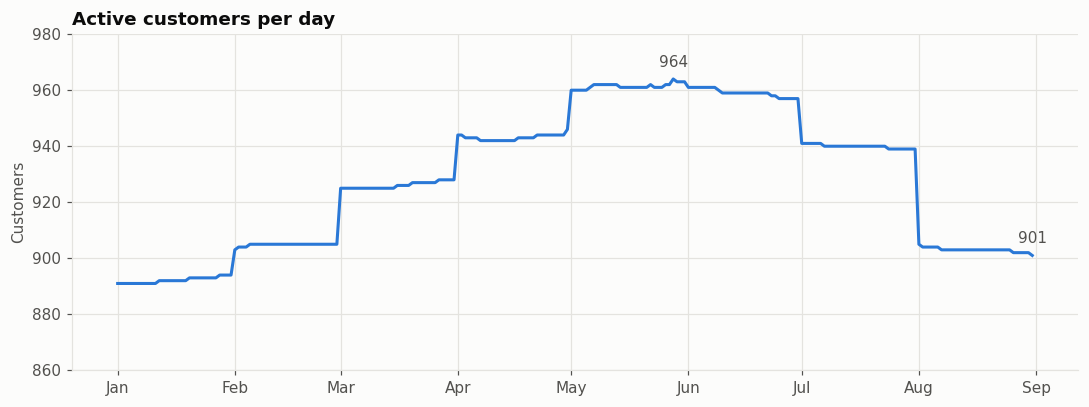

In [23]:
# Figure 1: customers active each day
active = data.sum(axis=1)
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(active.index, active.values, color=CLUSTER_COLORS[1])
for d in [active.idxmax(), active.index[-1]]:
    ax.annotate(f'{active[d]:,}', (d, active[d]), textcoords='offset points', xytext=(0, 8),
                ha='center', color=INK_2)
ax.set_title('Active customers per day')
ax.set_ylabel('Customers')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_ylim(860, 980)
plt.tight_layout(); plt.show()

The customer base grows from 891 to a peak of 964 at the end of May, then shrinks to 901 by the end of August. The steps are sharp and happen at month boundaries, which the next two charts explain.

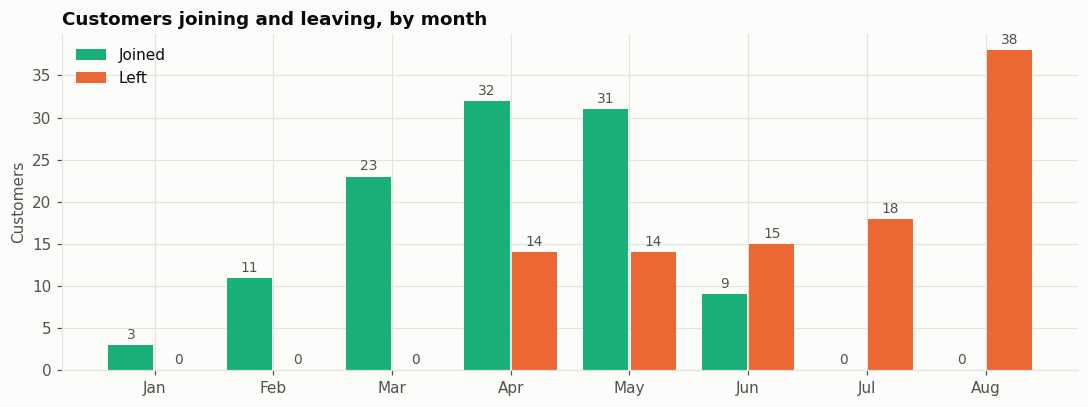

In [24]:
# Figure 2: customers joining and leaving each month
joins_m = join_events.groupby(periods).sum().sum(axis=1)
leaves_m = leave_events.groupby(periods).sum().sum(axis=1)

x = np.arange(len(months)); w = 0.38
fig, ax = plt.subplots(figsize=(10, 3.8))
b1 = ax.bar(x - w/2 - 0.01, joins_m.values, w, color=CLUSTER_COLORS[3], label='Joined')
b2 = ax.bar(x + w/2 + 0.01, leaves_m.values, w, color=CLUSTER_COLORS[2], label='Left')
for bars in (b1, b2):
    ax.bar_label(bars, padding=2, color=INK_2, fontsize=9)
ax.set_xticks(x, month_names)
ax.set_title('Customers joining and leaving, by month')
ax.set_ylabel('Customers')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

**Curiosities in this chart:**

- **No one left in January–March.** Churn only starts in April, then holds at 14–18 a month before jumping to 38 in August.
- **New customers stop after June.** Joins peak at 31–32 a month in April–May, drop to 9 in June and are zero in July and August. Growth turns into decline at the point where acquisition stops *and* churn rises.
- **Everyone joins at most once and leaves at most once.** This follows from how the data was built (see section 1). No customer leaves and later comes back.

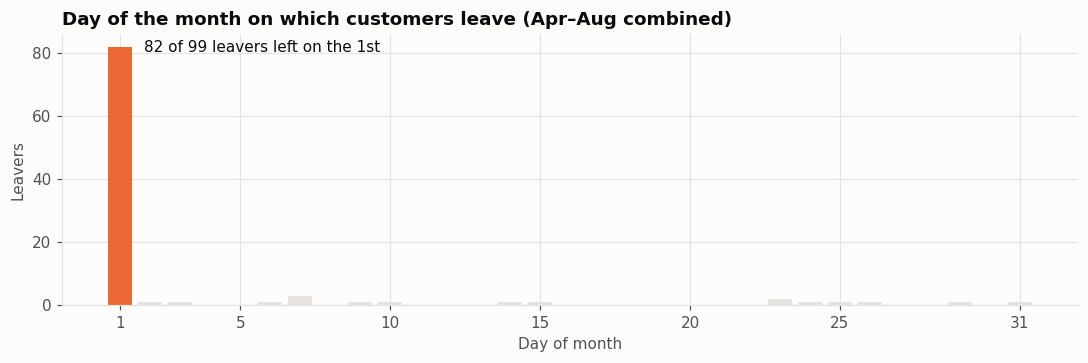

Joins on the 1st of a month: 89 of 109


In [25]:
# Figure 3: on which day of the month do customers leave?
leave_by_dom = leave_events.sum(axis=1)
leave_by_dom = leave_by_dom[leave_by_dom > 0].groupby(leave_by_dom[leave_by_dom > 0].index.day).sum()
leave_by_dom = leave_by_dom.reindex(range(1, 32), fill_value=0)
join_by_dom = join_events.sum(axis=1)
join_by_dom = join_by_dom[join_by_dom > 0].groupby(join_by_dom[join_by_dom > 0].index.day).sum()

fig, ax = plt.subplots(figsize=(10, 3.4))
colors = [CLUSTER_COLORS[2] if d == 1 else GRID for d in leave_by_dom.index]
ax.bar(leave_by_dom.index, leave_by_dom.values, color=colors, width=0.8)
ax.text(1.8, leave_by_dom[1], f'{leave_by_dom[1]} of {leave_by_dom.sum()} leavers left on the 1st',
        va='center', color=INK)
ax.set_title('Day of the month on which customers leave (Apr–Aug combined)')
ax.set_xlabel('Day of month'); ax.set_ylabel('Leavers')
ax.set_xticks([1, 5, 10, 15, 20, 25, 31])
plt.tight_layout(); plt.show()

print(f'Joins on the 1st of a month: {join_by_dom.get(1, 0)} of {int(join_by_dom.sum())}')

**Curiosity: churn happens on the 1st.** 82 of the 99 departures, and 89 of the 109 joins, happen on the first day of a month. That pattern fits supplier switches, which usually take effect at the start of a month. So "churn in month M" really means "switches that took effect on the 1st of M", which were arranged during the previous month. This timing is the key to reading August's spike later on.

In [26]:
# Who leaves: customers active since 1 Jan, or customers who joined during the window?
first_day = data.idxmax().where(data.max() == 1)
left_day = leave_events.idxmax().where(leave_events.any())
who = pd.DataFrame({'first_day': first_day, 'left_day': left_day})
who['original'] = who['first_day'] == data.index[0]
leavers = who.dropna(subset=['left_day'])

orig_total, new_total = int(who['original'].sum()), int((~who['original'] & who['first_day'].notna()).sum())
print(f"Original customers (active 1 Jan): {int(leavers['original'].sum())} of {orig_total} left "
      f"({100 * leavers['original'].sum() / orig_total:.1f}%)")
print(f"Customers who joined during the window: {int((~leavers['original']).sum())} of {new_total} left "
      f"({100 * (~leavers['original']).sum() / new_total:.1f}%)")

Original customers (active 1 Jan): 93 of 891 left (10.4%)
Customers who joined during the window: 6 of 109 left (5.5%)


**Curiosity: nearly all leavers are long-standing customers.** 93 of the 99 leavers were already customers on 1 January. Recent joiners are *not* churning faster, so there's no "trial customers dropping out" effect. Churn grows with the calendar, not with how long someone has been a customer, and that rules out tenure-based retention models (section 5).

## 3. Defining and calculating churn

For each month *M*:

- **Starting group (cohort):** customers active on the **last day of month M−1**. For January, it's customers active on **1 January**.
- **Leavers:** members of that group who are inactive on **any day of month M**.
- **Churn rate** = leavers ÷ starting group.
- **Absolute churn** = number of customers who leave on any day of M.

Customers who join during M aren't in that month's starting group, so they can't count toward its churn rate. In this data nobody joins and leaves within the same month, so absolute churn equals the number of leavers every month. The two are still computed separately in case that ever changes.

In [27]:
def churn_panel(pods_by_cluster):
    # One row per (cluster, month): starting group, leavers, absolute churn, churn rate
    rows = []
    for cid, pods in pods_by_cluster.items():
        sub = data[pods]
        for t, month in enumerate(months, start=1):
            month_days = sub[periods == month]
            if t == 1:                                            # January: baseline is 1 Jan
                base = month_days.index.min()
                check = month_days.loc[month_days.index > base]
            else:                                                 # other months: last day of M-1
                base = sub[periods == months[t - 2]].index.max()
                check = month_days
            cohort = sub.loc[base] == 1
            left = (check.loc[:, cohort] == 0).any(axis=0)        # inactive on any day of M
            rows.append({
                'cluster': cid, 't': t, 'month': month.strftime('%b'),
                'cohort': int(cohort.sum()),
                'leavers': int(left.sum()),
                'absolute_churn': int(leave_events.loc[periods == month, pods].any(axis=0).sum()),
            })
    out = pd.DataFrame(rows)
    out['churn_rate_%'] = (100 * out['leavers'] / out['cohort']).round(2)
    return out

pods_by_cluster = {c: [p for p in pod_to_cluster[pod_to_cluster == c].index if p in data.columns]
                   for c in cluster_ids}
panel = churn_panel(pods_by_cluster)
panel_all = churn_panel({'All': list(data.columns)})

print('Churn rate (%) by cluster:')
rate_tbl = panel.pivot(index='t', columns='cluster', values='churn_rate_%')
rate_tbl['All'] = panel_all.set_index('t')['churn_rate_%']
rate_tbl.index = month_names
display(rate_tbl)

print('Absolute churn (customers who left) by cluster:')
abs_tbl = panel.pivot(index='t', columns='cluster', values='absolute_churn')
abs_tbl['All'] = panel_all.set_index('t')['absolute_churn']
abs_tbl.index = month_names
display(abs_tbl)

Churn rate (%) by cluster:


cluster,1,2,3,4,5,All
Jan,0.00,0.00,0.00,0.00,0.00,0.00
Feb,0.00,0.00,0.00,0.00,0.00,0.00
Mar,0.00,0.00,0.00,0.00,0.00,0.00
Apr,1.40,5.71,0.00,0.00,1.32,1.51
May,1.13,6.06,3.45,0.00,2.50,1.48
Jun,1.71,3.23,0.00,0.00,0.00,1.56
Jul,1.72,3.23,0.00,16.67,2.50,1.88
Aug,4.14,3.33,7.14,20.00,1.28,4.05


Absolute churn (customers who left) by cluster:


cluster,1,2,3,4,5,All
Jan,0,0,0,0,0,0
Feb,0,0,0,0,0,0
Mar,0,0,0,0,0,0
Apr,11,2,0,0,1,14
May,9,2,1,0,2,14
Jun,14,1,0,0,0,15
Jul,14,1,0,1,2,18
Aug,33,1,2,1,1,38


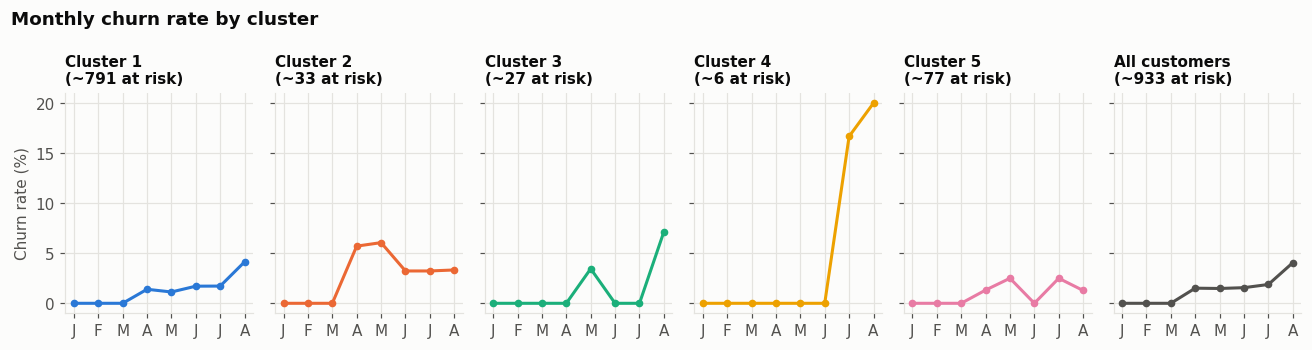

In [28]:
# Figure 4: churn rate by cluster, one small panel per cluster (shared y-axis)
fig, axes = plt.subplots(1, 6, figsize=(12, 3.2), sharey=True)
series = [(c, panel[panel['cluster'] == c], CLUSTER_COLORS[c], f'Cluster {c}') for c in cluster_ids]
series.append(('All', panel_all, ALL_COLOR, 'All customers'))
for ax, (cid, df, color, title) in zip(axes, series):
    ax.plot(df['t'], df['churn_rate_%'], color=color, marker='o', markersize=4)
    n = int(df['cohort'].iloc[0]) if cid != 'All' else int(df['cohort'].iloc[0])
    ax.set_title(f'{title}\n(~{int(df["cohort"].median())} at risk)', fontsize=10)
    ax.set_xticks(range(1, 9), [m[0] for m in month_names])
axes[0].set_ylabel('Churn rate (%)')
fig.suptitle('Monthly churn rate by cluster', x=0.01, ha='left', fontweight='bold', color=INK)
plt.tight_layout(); plt.show()

Cluster 1 (85% of customers) looks just like the portfolio as a whole: flat at zero until March, about 1.5% from April, and a jump in August. The small clusters zig-zag. Cluster 4 reaches 17–20% in July and August, but that's 1 customer out of 6, and then 1 out of 5.

## 4. Do clusters churn differently?

Clusters 2 and 4 *look* like they churn more. Before building that into a forecast, it's worth testing whether the gap is bigger than chance would produce. I compare two explanations of April–July churn (the months when churn happens):

- **Same rate:** every cluster has the portfolio's churn rate.
- **Own rate:** each cluster has its own churn rate.

A likelihood-ratio test checks whether separate rates explain the data meaningfully better. Because the counts are small, I also compute the p-value by simulation instead of relying only on the chi-square approximation.

In [29]:
q = panel[panel['t'].between(4, 7)].groupby('cluster')[['leavers', 'cohort']].sum()
q['churn_rate_%'] = (100 * q['leavers'] / q['cohort']).round(2)
display(q)

def binom_ll(y, n, r):
    r = np.clip(r, 1e-12, 1 - 1e-12)
    return np.sum(y * np.log(r) + (n - y) * np.log(1 - r))

y, n = q['leavers'].values, q['cohort'].values
pooled = y.sum() / n.sum()
lr = 2 * (binom_ll(y, n, y / n) - binom_ll(y, n, pooled))
p_asym = 1 - chi2.cdf(lr, df=len(q) - 1)

rng = np.random.default_rng(0)                   # simulate the 'same rate' world 20,000 times
sim = rng.binomial(n, pooled, size=(20000, len(n)))
lr_sim = np.array([2 * (binom_ll(s, n, s / n) - binom_ll(s, n, s.sum() / n.sum())) for s in sim])
p_sim = np.mean(lr_sim >= lr)
print(f'Likelihood-ratio statistic {lr:.2f}: p = {p_asym:.3f} (chi-square), p = {p_sim:.3f} (simulation)')

,leavers,cohort,churn_rate_%
cluster,,,
1,48,3213,1.49
2,6,130,4.62
3,1,112,0.89
4,1,24,4.17
5,5,315,1.59


Likelihood-ratio statistic 6.35: p = 0.175 (chi-square), p = 0.191 (simulation)


**Curiosity: the behavioural clusters don't show clearly different churn.** With p ≈ 0.18–0.19, the gaps between clusters are well within what random variation produces at these sample sizes. Cluster 2 (4.6% over April–July) is the most suggestive, but that's 6 leavers. The clusters describe *how* customers use electricity, which isn't necessarily *whether* they leave.

This doesn't prove the clusters are identical, only that the data can't yet tell them apart. The forecasting model should therefore let clusters differ, but pull them toward the shared rate unless the evidence is strong. That is exactly what a hierarchical model does.

## 5. Choosing a forecasting model

The earlier straight-line trend has three problems here: it treats a 6-customer cluster the same as an 846-customer cluster, it can predict negative churn, and it gives no uncertainty range. I considered the standard alternatives:

| Approach | Fit for this data |
|---|---|
| **Poisson regression with an exposure offset** | ✔ The standard model for "how many events out of *n* at risk". The rate is modelled per customer at risk and scaled by that month's starting group ([The Analysis Factor](https://www.theanalysisfactor.com/the-exposure-variable-in-poission-regression-models/)). |
| **Hierarchical (partial-pooling) cluster effects** | ✔ Small groups borrow strength from the whole: each cluster's level is pulled toward the shared rate, and small clusters are pulled most ([rstanarm vignette](https://cran.r-project.org/web/packages/rstanarm/vignettes/pooling.html)). Matches the section 4 finding. |
| **Shifted-beta-geometric retention model** ([Fader & Hardie](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=801145)) | ✘ The classic subscription-retention model, but it assumes churn *falls* as customers stay longer. Here churn *rises* with the calendar, and long-standing customers are the ones leaving (section 2). |
| **Per-customer classifiers** (logistic regression etc.) | ✘ The daily 0/1 flags give almost no warning before someone leaves: customers are fully active until the day they switch. |

**Chosen: a Bayesian hierarchical Poisson model.** It's fitted with MCMC in plain numpy (statsmodels and PyMC weren't available), so the notebook needs only numpy, pandas, scipy and matplotlib.

## 6. The model: Bayesian hierarchical Poisson

For cluster *c* in month *t*:

$$\text{leavers}_{c,t} \sim \text{Poisson}\big(\text{cohort}_{c,t} \cdot e^{\,\alpha + \beta t + u_c}\big), \qquad u_c = \sigma z_c,\; z_c \sim \mathcal N(0,1)$$

| Piece | Meaning |
|---|---|
| `cohort ×` | exposure: the model predicts a rate per customer at risk, then scales by how many are at risk |
| $\alpha$ | overall baseline rate (log scale) |
| $\beta$ | shared monthly trend; $e^{\beta}$ is the month-on-month multiplier, e.g. 1.07 = +7% |
| $u_c$ | cluster adjustment, drawn from a shared distribution with spread $\sigma$ |
| priors | $\alpha \sim N(-4, 2^2)$ (≈2% a month, very loose), $\beta \sim N(0, 0.5^2)$ (no trend assumed), $\sigma \sim \text{HalfNormal}(0.5)$ (modest cluster differences, never forced to zero) |

**Fitting:** adaptive Metropolis MCMC. The sampler takes tens of thousands of small random steps through parameter space and keeps steps in proportion to how well they fit, so the kept samples describe both the best estimates and their uncertainty. Step sizes are tuned during a warm-up ("burn-in") that is then discarded.

**Forecasting:** for each kept sample, compute the August rate and draw a random leaver count. The spread of those simulated counts gives the prediction ranges, covering both uncertainty in the rate and ordinary month-to-month randomness.

Two switches create the model variants tested in section 7: `trend` (on/off) and `start_t` (fit from January, or from April when churn began).

In [30]:
SEED = 42 # the answer to life the universe and everything

class BayesHierPoisson:
    # Poisson rate model: shared intercept + optional trend + partially pooled cluster effect
    def __init__(self, trend=True, start_t=1, name=None, seed=SEED):
        self.trend, self.start_t, self.seed = trend, start_t, seed
        self.name = name or f"Hierarchical Poisson ({'trend' if trend else 'flat'}, from month {start_t})"

    def _logpost(self, p):
        # log posterior = Poisson log-likelihood + log priors
        a, b, log_s, z = p[0], p[1], p[2], p[3:]
        s = np.exp(log_s)
        eta = a + (b * self.t if self.trend else 0.0) + s * z[self.ci]  # log churn rate per row
        ll = np.sum(self.y * eta - self.n * np.exp(eta))                 # Poisson kernel with exposure
        lp = (-0.5 * ((a + 4) / 2) ** 2                                  # alpha ~ N(-4, 2^2)
              - 0.5 * (b / 0.5) ** 2                                     # beta  ~ N(0, 0.5^2)
              - 0.5 * (s / 0.5) ** 2 + log_s                             # sigma ~ HalfNormal(0.5) (+ Jacobian)
              - 0.5 * np.sum(z ** 2))                                    # z_c   ~ N(0, 1)
        return ll + lp

    def fit(self, df, iters=40000, burn=10000, thin=10):
        df = df[df['t'] >= self.start_t]
        self.cids = sorted(df['cluster'].unique())
        self.ci = df['cluster'].map({c: i for i, c in enumerate(self.cids)}).values
        self.t, self.y, self.n = df['t'].values.astype(float), df['leavers'].values, df['cohort'].values
        rng = np.random.default_rng(self.seed)
        k = 3 + len(self.cids)
        p = np.r_[np.log(max(self.y.sum(), 0.5) / self.n.sum()), 0.0, np.log(0.2), np.zeros(len(self.cids))]
        lp, cov, chain, hist = self._logpost(p), np.eye(k) * 0.01, [], []
        for i in range(iters):
            prop = p + rng.multivariate_normal(np.zeros(k), cov * 2.38 ** 2 / k)   # propose a step
            if not self.trend:
                prop[1] = 0.0
            lp_prop = self._logpost(prop)
            if np.log(rng.random()) < lp_prop - lp:                             # Metropolis accept/reject
                p, lp = prop, lp_prop
            hist.append(p.copy())
            if 2000 <= i < burn and i % 500 == 0:                                # tune steps during burn-in
                cov = np.cov(np.array(hist[-5000:]).T) + np.eye(k) * 1e-6
            if i >= burn and i % thin == 0:                                      # keep every 10th sample
                chain.append(p.copy())
        self.chain = np.array(chain)
        return self

    def predictive(self, cid, t, n, rng):
        # Simulated leaver counts (and the rates behind them) for cluster cid, month t, n at risk
        a, b, s = self.chain[:, 0], self.chain[:, 1], np.exp(self.chain[:, 2])
        z = self.chain[:, 3 + self.cids.index(cid)]
        rate = np.exp(a + (b * t if self.trend else 0.0) + s * z)
        return rng.poisson(n * rate), rate

    def predict_mean(self, cid, t, n):
        return n * self.predictive(cid, t, n, np.random.default_rng(self.seed))[1].mean()

# Simple benchmarks the model has to beat
class LastMonthRate:
    name = "Benchmark: repeat last month's cluster rate"
    def fit(self, df): self.df = df; return self
    def predict_mean(self, cid, t, n):
        r = self.df[(self.df['cluster'] == cid) & (self.df['t'] == t - 1)].iloc[0]
        return n * r['leavers'] / r['cohort']

class PooledRecentRate:
    name = 'Benchmark: portfolio rate, last 3 months'
    def fit(self, df): self.df = df; return self
    def predict_mean(self, cid, t, n):
        g = self.df[self.df['t'].between(t - 3, t - 1)]
        return n * g['leavers'].sum() / g['cohort'].sum()

def poisson_deviance(y, mu):
    # Lower = better. Scores count forecasts fairly: missing 0 with 3 is worse than missing 15 with 18
    y, mu = np.asarray(y, float), np.maximum(np.asarray(mu, float), 1e-9)
    term = np.where(y > 0, y * np.log(np.where(y > 0, y, 1) / mu), 0.0)
    return float(2 * np.sum(term - (y - mu)))

## 7. Backtest: which model forecasts best?

To choose a model without peeking at August, each candidate forecasts a month it hasn't seen, using only earlier data:

- train on **January–May**, forecast **June**
- train on **January–June**, forecast **July**

The five candidates are two simple benchmarks and three versions of the hierarchical model. The version fitted from April tests whether the January–March zeros should be left out of the trend.

In [31]:
def make_candidates():
    return [
        LastMonthRate(),
        PooledRecentRate(),
        BayesHierPoisson(trend=True,  start_t=1, name='Hierarchical Poisson, trend, fit from Jan'),
        BayesHierPoisson(trend=True,  start_t=4, name='Hierarchical Poisson, trend, fit from Apr'),
        BayesHierPoisson(trend=False, start_t=4, name='Hierarchical Poisson, flat, fit from Apr'),
    ]

bt = []
for target in (6, 7):
    train, test = panel[panel['t'] < target], panel[panel['t'] == target]
    for m in make_candidates():
        m.fit(train)
        preds = np.array([m.predict_mean(r.cluster, target, r.cohort) for r in test.itertuples()])
        bt.append({'model': m.name, 'target': month_names[target - 1],
                   'pred_total': preds.sum(), 'actual_total': test['leavers'].sum(),
                   'abs_err': np.abs(preds - test['leavers'].values).sum(),
                   'deviance': poisson_deviance(test['leavers'], preds)})
bt = pd.DataFrame(bt)

backtest = bt.groupby('model', sort=False).agg(
    jun_predicted=('pred_total', 'first'), jul_predicted=('pred_total', 'last'),
    error_per_cluster=('abs_err', lambda s: s.sum() / (2 * len(cluster_ids))),
    deviance=('deviance', 'sum')).round(2)
print(f"Actual leavers: Jun {int(bt['actual_total'].iloc[0])}, Jul {int(bt['actual_total'].iloc[-1])}")
display(backtest)
best_name = backtest['deviance'].idxmin()
print(f'Selected (lowest deviance): {best_name}')

Actual leavers: Jun 15, Jul 18


,jun_predicted,jul_predicted,error_per_cluster,deviance
model,,,,
Benchmark: repeat last month's cluster rate,14.06,14.88,1.17,129.61
"Benchmark: portfolio rate, last 3 months",9.70,14.51,1.19,11.46
"Hierarchical Poisson, trend, fit from Jan",35.57,34.09,3.82,33.03
"Hierarchical Poisson, trend, fit from Apr",15.23,15.71,0.75,8.75
"Hierarchical Poisson, flat, fit from Apr",14.34,14.62,0.91,9.10


Selected (lowest deviance): Hierarchical Poisson, trend, fit from Apr


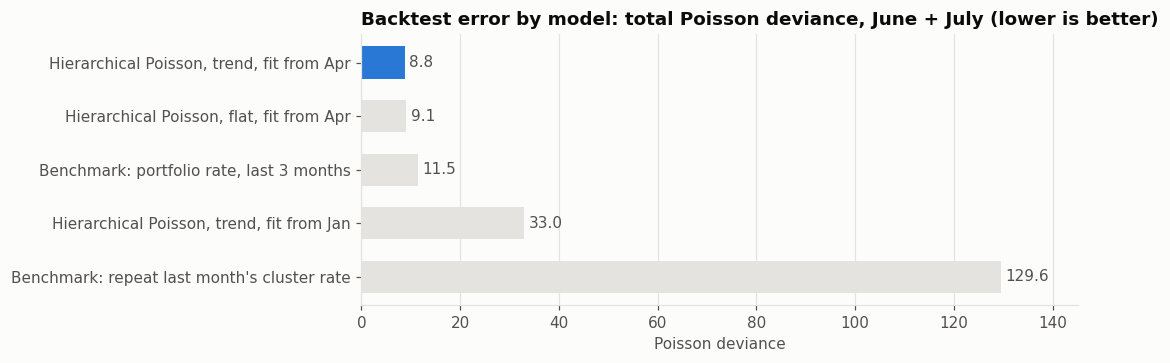

In [32]:
# Figure 5: backtest error by model (lower is better)
order = backtest.sort_values('deviance', ascending=False)
fig, ax = plt.subplots(figsize=(10, 3.4))
colors = [CLUSTER_COLORS[1] if name == best_name else GRID for name in order.index]
bars = ax.barh(order.index, order['deviance'], color=colors, height=0.6)
ax.bar_label(bars, fmt='%.1f', padding=3, color=INK_2)
ax.set_title('Backtest error by model: total Poisson deviance, June + July (lower is better)')
ax.set_xlabel('Poisson deviance'); ax.grid(axis='y', visible=False)
ax.set_xlim(0, order['deviance'].max() * 1.12)
plt.tight_layout(); plt.show()

**Takeaways from the backtest:**

- **The January–March zeros wreck a trend fitted from January.** Three zero months followed by ~1.5% make the trend climb far too steeply, and it predicts about 35 leavers for both June and July (actual: 15 and 18).
- **Fitting from April wins**, with the lowest deviance and about 0.75 leavers of error per cluster. Churn behaves like something that *switched on* in April, not a smooth curve from January.
- **"Repeat last month" gets the totals roughly right but is badly wrong for small clusters.** When a small cluster happens to have 0 leavers, it predicts 0 for next month, and deviance penalises that heavily.

## 8. August forecast

The selected model is refitted on all data through July. Since it fits from April, that's April–July, run longer for precision. It then forecasts August. August's starting group (customers active on 31 July) is known at the end of July, so using it doesn't leak any future information.

First, a check that the MCMC has converged. Three independent runs should agree, which means R-hat close to 1.00.

In [33]:
final_train = panel[panel['t'] <= 7]
runs = [BayesHierPoisson(trend=True, start_t=4, seed=s).fit(final_train, iters=80000, burn=20000)
        for s in (42, 7, 2026)]
C = np.array([r.chain for r in runs])                 # (runs, samples, parameters)
W = C.var(axis=1, ddof=1).mean(axis=0)
B = C.shape[1] * C.mean(axis=1).var(axis=0, ddof=1)
rhat = np.sqrt(((C.shape[1] - 1) / C.shape[1] * W + B / C.shape[1]) / W)
print('R-hat (alpha, beta, log sigma, z1..z5):', np.round(rhat, 3))

model = runs[0]
ch = model.chain
beta, sigma = ch[:, 1], np.exp(ch[:, 2])
print(f'Trend: x{np.exp(beta.mean()):.2f} per month '
      f'(90% interval x{np.exp(np.percentile(beta, 5)):.2f} to x{np.exp(np.percentile(beta, 95)):.2f})')
print(f'Cluster spread sigma: {sigma.mean():.2f}')

R-hat (alpha, beta, log sigma, z1..z5): [1.001 1.    1.    1.001 1.    1.    1.001 1.   ]
Trend: x1.07 per month (90% interval x0.90 to x1.28)
Cluster spread sigma: 0.37


R-hat is 1.00 for every parameter, so the runs agree. The trend is mild (about +7% a month) and its interval includes "no trend". Before August, churn was essentially flat at about 1.5–1.9%.

In [34]:
rng = np.random.default_rng(SEED)
aug = panel[panel['t'] == 8].set_index('cluster')
rows, total_draws, count_draws = [], 0, {}
for cid in cluster_ids:
    n = int(aug.loc[cid, 'cohort'])
    draws, rate = model.predictive(cid, 8, n, rng)
    total_draws = total_draws + draws
    count_draws[cid] = draws
    rows.append({'cluster': cid, 'at_risk_jul31': n,
                 'predicted': round(draws.mean(), 1),
                 'range_80%': f'{int(np.percentile(draws, 10))}–{int(np.percentile(draws, 90))}',
                 'range_95%': f'{int(np.percentile(draws, 2.5))}–{int(np.percentile(draws, 97.5))}',
                 'predicted_rate_%': round(100 * rate.mean(), 2),
                 'actual': int(aug.loc[cid, 'leavers']),
                 'actual_rate_%': round(aug.loc[cid, 'churn_rate_%'], 2)})
n_all = int(aug['cohort'].sum())
rows.append({'cluster': 'All', 'at_risk_jul31': n_all,
             'predicted': round(total_draws.mean(), 1),
             'range_80%': f'{int(np.percentile(total_draws, 10))}–{int(np.percentile(total_draws, 90))}',
             'range_95%': f'{int(np.percentile(total_draws, 2.5))}–{int(np.percentile(total_draws, 97.5))}',
             'predicted_rate_%': round(100 * total_draws.mean() / n_all, 2),
             'actual': int(aug['leavers'].sum()),
             'actual_rate_%': round(100 * aug['leavers'].sum() / n_all, 2)})
forecast = pd.DataFrame(rows).set_index('cluster')
display(forecast)
print(f"Chance of 38 or more leavers under the model: {np.mean(total_draws >= 38):.2%}")

,at_risk_jul31,predicted,range_80%,range_95%,predicted_rate_%,actual,actual_rate_%
cluster,,,,,,,
1,798,15.0,8–23,6–28,1.87,33,4.14
2,30,0.9,0–2,0–4,3.16,1,3.33
3,28,0.6,0–2,0–3,2.04,2,7.14
4,5,0.1,0–1,0–1,2.55,1,20.00
5,78,1.6,0–4,0–5,2.06,1,1.28
All,939,18.2,10–27,7–34,1.94,38,4.05


Chance of 38 or more leavers under the model: 0.93%


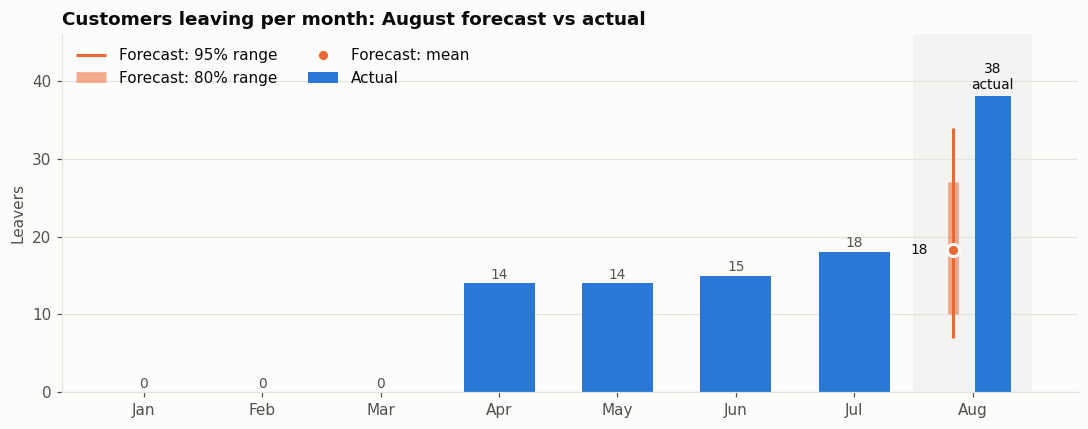

In [35]:
# Figure 6: monthly leavers, Jan-Jul actual, August forecast vs actual
monthly = panel_all.set_index('t')['leavers']
lo95, hi95 = np.percentile(total_draws, [2.5, 97.5])
lo80, hi80 = np.percentile(total_draws, [10, 90])

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, 8), monthly.loc[1:7], color=CLUSTER_COLORS[1], width=0.6, label='Actual')
ax.bar(8.17, monthly.loc[8], color=CLUSTER_COLORS[1], width=0.3)
ax.vlines(7.83, lo95, hi95, color=ACCENT, lw=2, label='Forecast: 95% range')
ax.vlines(7.83, lo80, hi80, color=ACCENT, lw=7, alpha=0.55, label='Forecast: 80% range')
ax.plot(7.83, total_draws.mean(), 'o', color=ACCENT, ms=8, mec=SURFACE, mew=2, label='Forecast: mean')
for t in range(1, 8):
    ax.text(t, monthly[t] + 0.6, str(monthly[t]), ha='center', color=INK_2, fontsize=9)
ax.text(8.17, monthly[8] + 0.6, f'{monthly[8]}\nactual', ha='center', va='bottom', color=INK, fontsize=9)
ax.text(7.62, total_draws.mean(), f'{total_draws.mean():.0f}', ha='right', va='center', color=INK, fontsize=9)
ax.axvspan(7.5, 8.5, color=GRID, alpha=0.35, lw=0, zorder=0)
ax.set_xticks(range(1, 9), month_names)
ax.set_ylim(0, 46)
ax.set_title('Customers leaving per month: August forecast vs actual')
ax.set_ylabel('Leavers'); ax.grid(axis='x', visible=False)
ax.legend(loc='upper left', ncol=2)
plt.tight_layout(); plt.show()

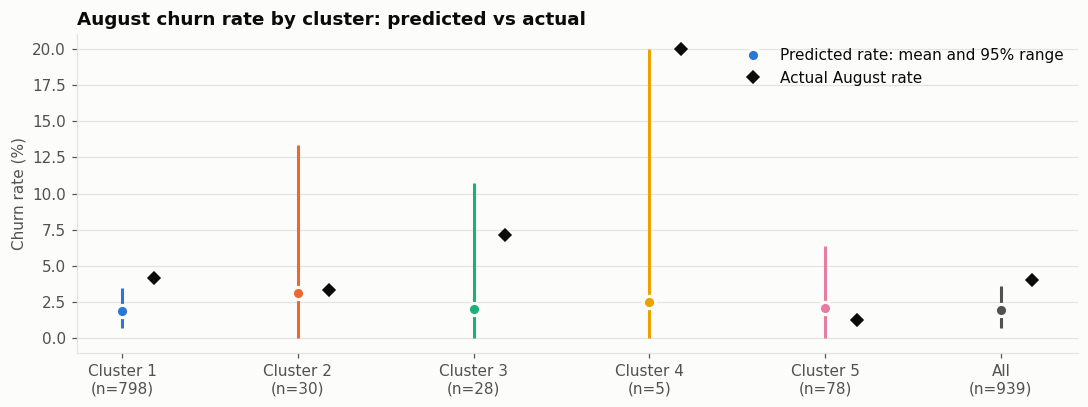

In [36]:
# Figure 7: predicted vs actual August churn rate, by cluster.
# The range is for the OBSERVED rate (simulated leavers / at risk), so it includes the
# month-to-month chance that dominates small clusters and is directly comparable to the actual.
fig, ax = plt.subplots(figsize=(10, 3.8))
labels = [f'Cluster {c}\n(n={int(aug.loc[c, "cohort"])})' for c in cluster_ids] + [f'All\n(n={n_all})']
for i, cid in enumerate(cluster_ids + ['All']):
    n_c = n_all if cid == 'All' else int(aug.loc[cid, 'cohort'])
    r = 100 * (total_draws if cid == 'All' else count_draws[cid]) / n_c
    lo, hi = np.percentile(r, [2.5, 97.5])
    color = ALL_COLOR if cid == 'All' else CLUSTER_COLORS[cid]
    ax.vlines(i, lo, hi, color=color, lw=2)
    ax.plot(i, r.mean(), 'o', color=color, ms=8, mec=SURFACE, mew=2,
            label='Predicted rate: mean and 95% range' if i == 0 else None)
    ax.plot(i + 0.18, forecast.loc[cid, 'actual_rate_%'], 'D', color=INK, ms=6,
            label='Actual August rate' if i == 0 else None)
ax.set_xticks(range(6), labels)
ax.set_ylabel('Churn rate (%)')
ax.set_title('August churn rate by cluster: predicted vs actual')
ax.grid(axis='x', visible=False)
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

**Reading the results:**

- **The forecast of about 18 leavers was a sound reading of January–July.** From April to July, churn held at 14–18 a month with no real trend, and every model that fitted that period well predicted 15–19.
- **August came in at 38, outside the 95% range.** Under the model the chance of 38 or more is under 1%, so this isn't an unlucky draw. Something changed.
- **The change is concentrated on 1 August:** 34 of the 38 left that day, against 9–16 on the 1st of earlier months. Customers switched away in a single wave, which is an outside event, not a gradual trend.
- **The prediction ranges for small clusters are wide by design.** Cluster 4 at 20% is 1 customer out of 5, and cluster 3 at 7% is 2 out of 28. Both actuals fall inside their 95% ranges. With so few customers, a single leaver is enough to produce a rate like that.
- **Cluster 1 alone explains the miss:** 33 leavers against about 15 predicted. The switching wave hit the mainstream customer base, not a niche cluster.

## 9. Conclusions

**What the data shows**
1. Churn started in April and held steady at **~1.5–1.9% a month** (14–18 customers) through July, then **doubled to 4.1% (38 customers) in August**.
2. **Churn happens on the 1st of the month**, as do joins, consistent with the supplier-switching calendar.
3. **The customers leaving are long-standing ones** (93 of 99 were customers on 1 January), so churn isn't a new-customer problem.
4. **Acquisition stopped after June** (no joins in July–August). Combined with rising churn, the customer base fell from 961 to 901.
5. **The consumption-based clusters don't reliably predict churn** (p ≈ 0.18). Cluster 1, with 85% of customers, drives the totals.

**What the model shows**
- A Bayesian hierarchical Poisson model with an exposure offset, fitted from when churn began (April), beat the simple benchmarks and the other variants on the June and July backtests.
- It forecast **18 leavers (1.9%) for August, 95% range 7–34**. The actual 38 was a switching wave on 1 August that January–July churn gave no sign of.

**How to improve the forecast**
- **Add information from outside the churn history.** Switches take effect on the 1st, so the next month's churn is partly known in advance through switching requests received by the grid operator, competitor price moves, tariff changes, and contract renewal dates. Any of these could enter the model as extra predictors.
- **Refit monthly.** With August included, the model's trend and uncertainty will widen appropriately. It's worth watching whether August was a one-off or the start of a new level.
- **Revisit the clusters for churn purposes.** Clusters built from consumption shape explain little about leaving. Segmenting by contract type, tariff or price exposure is more likely to show churn differences.

**Sources**
- [The Exposure Variable in Poisson Regression Models – The Analysis Factor](https://www.theanalysisfactor.com/the-exposure-variable-in-poission-regression-models/)
- [Person-Time and Poisson Rate Modeling Explained – MetricGate](https://metricgate.com/blogs/person-time-poisson-rate-modeling/)
- [Hierarchical Partial Pooling for Repeated Binary Trials – rstanarm](https://cran.r-project.org/web/packages/rstanarm/vignettes/pooling.html)
- [Shrinkage and Partial Pooling Explained – MetricGate](https://metricgate.com/blogs/shrinkage-in-mixed-models/)
- [How to Project Customer Retention – Fader & Hardie](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=801145)